# gpbayeskit — Tutorial

A step-by-step guide to fitting, predicting, and visualising Gaussian process models
with **gpbayeskit**.

**Topics covered**
1. Installation & imports
2. Spatial simulation
3. Spatial GP models: family: matern and ch; form: isotropic, ARD, tensor
4. Model fitting — fixing and initialising parameters
5. Prediction and scoring
6. Using the kernel builder directly
7. Log-likelihood profile plots
8. Space-time covariance plots (1-D and 2-D)
9. Space-time simulation and realisation plots


## 1  Installation


In [1]:
# Install from the repo root (run once in a terminal, not inside the notebook)
# pip install -e ".[plot]"

import numpy as np
import matplotlib.pyplot as plt

import gpbayeskit as gp
from gpbayeskit.plotting import (
    plot_loglik,
    plot_loglik_panel,
    plot_cov_st_1d,
    plot_cov_st_2d,
)


## 2  Spatial simulation


In [2]:
# Simulate from a spatial GP on a 2-D unit square
rng   = np.random.default_rng(42)
X_all = rng.uniform(0, 1, (120, 2))

sim = gp.simulate(
    X_all,
    kernel_type   = "matern52",    # Matérn ν = 2.5
    kernel_form   = "isotropic",
    phi           = 0.25,          # spatial range
    sigma2        = 1.5,           # marginal variance
    nugget        = 0.05,          # 5 % noise
    return_latent = True,          # also return the noise-free draw
    seed          = 42,
)

print(f"y      shape: {sim.y.shape}")
print(f"latent shape: {sim.latent.shape}")
print(f"cov    shape: {sim.cov.shape}")


y      shape: (120, 1)
latent shape: (120, 1)
cov    shape: (120, 120)


In [3]:
# Train / test split
idx_train = rng.choice(120, 80, replace=False)
idx_test  = np.setdiff1d(np.arange(120), idx_train)

X_train, y_train = X_all[idx_train], sim.y[idx_train]
X_test,  y_test  = X_all[idx_test],  sim.y[idx_test]

print(f"Train: {X_train.shape[0]}   Test: {X_test.shape[0]}")


Train: 80   Test: 40


## 3  Model construction


In [4]:
# 3a. Isotropic Matérn 5/2
gp_iso = gp.SpatialGP(X_train, y_train,
                       kernel_type="matern52",
                       kernel_form="isotropic")
print(gp_iso)

# 3b. ARD Matérn — one length-scale per spatial dimension
gp_ard = gp.SpatialGP(X_train, y_train,
                       kernel_type="matern",
                       kernel_form="ard")
print(gp_ard)

# 3c. Tensor-product Gaussian kernel
gp_tensor = gp.SpatialGP(X_train, y_train,
                          kernel_type="gauss",
                          kernel_form="tensor")
print(gp_tensor)

# 3d. CH (confluent hypergeometric) kernel — free tail parameter
gp_ch = gp.SpatialGP(X_train, y_train, kernel_type="ch")
print(gp_ch)

# 3e. Spatio-temporal GP (Lagrangian Matérn)
#     X must have shape (n, d_space + 1): last column is time
t_all     = rng.uniform(0, 2, (120, 1))
Xst_all   = np.hstack([X_all, t_all])
Xst_train = Xst_all[idx_train]
Xst_test  = Xst_all[idx_test]

gp_st = gp.SpatioTemporalGP(Xst_train, y_train,
                              model="lagrangian_matern",
                              d_space=2)
print(gp_st)


SpatialGP(n=80, d=2, kernel='matern52/isotropic', status=unfitted)
SpatialGP(n=80, d=2, kernel='matern/ard', status=unfitted)
SpatialGP(n=80, d=2, kernel='gauss/tensor', status=unfitted)
SpatialGP(n=80, d=2, kernel='ch/isotropic', status=unfitted)
SpatioTemporalGP(n=80, d_space=2, model='lagrangian_matern', status=unfitted)


## 4  Model fitting


In [5]:
# 4a. Simple fit — all free parameters optimised from defaults
gp_iso.fit()
gp_iso.summary()


SpatialGP — fit summary
────────────────────────────────────────────
  phi                 : 0.283925  # Range / scale
  nu                  : 2.5  # Matérn smoothness
  tail                : 0.5  # CH tail shape (α)
  nugget              : 0.0741754  # Nugget ratio
  sigma2_hat          : 0.611534
  loglik              : -68.6632


{'phi': 0.2839253840087512,
 'nu': 2.5,
 'tail': 0.5,
 'nugget': 0.07417544477689207,
 'sigma2_hat': 0.6115343929304994,
 'loglik': -68.66324454732003}

In [6]:
# 4b. Fix smoothness ν; provide a starting value for phi
gp_ard.fit(fix_nu=1.5, phi_init=0.3)
gp_ard.summary()


SpatialGP — fit summary
────────────────────────────────────────────
  phi                 : [0.441343, 0.460204]  # Range / scale
  nu                  : 1.5  # Matérn smoothness
  tail                : 0.5  # CH tail shape (α)
  nugget              : 0.0586299  # Nugget ratio
  sigma2_hat          : 0.701611
  loglik              : -68.3795


{'phi': array([0.44134324, 0.46020358]),
 'nu': 1.5,
 'tail': 0.5,
 'nugget': 0.0586299124941155,
 'sigma2_hat': 0.7016113487368698,
 'loglik': -68.37947224726985}

In [7]:
# 4c. Fix nugget to a small constant; let tail be free (CH kernel)
gp_ch.fit(fix_nugget=0.01, fix_nu=1.5)
gp_ch.summary()


SpatialGP — fit summary
────────────────────────────────────────────
  phi                 : 0.61238  # Range / scale
  nu                  : 1.5  # Matérn smoothness
  tail                : 0.0948646  # CH tail shape (α)
  nugget              : 0.01  # Nugget ratio
  sigma2_hat          : 3.93147
  loglik              : -68.4522


{'phi': 0.6123804137216177,
 'nu': 1.5,
 'tail': 0.09486458190224492,
 'nugget': 0.01,
 'sigma2_hat': 3.9314665283671237,
 'loglik': -68.45223447940262}

In [8]:
# 4d. Spatio-temporal — fix ν and nugget to reduce runtime
gp_st.fit(fix_nu=1.5, fix_nugget=0.01)
gp_st.summary()


SpatioTemporalGP (lagrangian_matern) — fit summary
──────────────────────────────────────────────────
  phi                   : 0.908151  # Spatial range φ
  nu                    : 1.5  # Smoothness ν
  tail                  : 0.5  # CH tail shape α
  nugget                : 0.01  # Nugget ratio
  lam0                  : 0.417024  # Advection magnitude λ₀
  theta0                : -0.404067  # Advection direction θ₀ (rad)
  rho                   : 0.931971  # Temporal range ρ
  lambda1               : 1.14071  # Λ eigenvalue 1
  lambda2               : 0.434481  # Λ eigenvalue 2
  theta_Lambda          : -0.00213259  # Λ rotation θ_Λ (rad)
  sigma2_hat            : 0.145059
  loglik                : -95.5894


{'phi': 0.9081513283394922,
 'nu': 1.5,
 'tail': 0.5,
 'nugget': 0.01,
 'lam0': 0.4170240413041554,
 'theta0': -0.4040673137465028,
 'rho': 0.9319710384845821,
 'lambda1': 1.140713802865928,
 'lambda2': 0.4344813114176049,
 'theta_Lambda': -0.0021325877742663165,
 'sigma2_hat': 0.14505920050806886,
 'loglik': -95.58942745206791}

## 5  Prediction and scoring


In [10]:
# Kriging mean + predictive variance
mean, var = gp_iso.predict(X_test)
print(f"mean shape: {mean.shape}   var shape: {var.shape}")

# Mean-only prediction (faster — skips variance)
mean_only = gp_iso.predict(X_test, return_var=False)
print(f"mean-only shape: {mean_only.shape}")

# 95 % prediction interval coverage
sd    = np.sqrt(var)
lower = mean - 1.96 * sd
upper = mean + 1.96 * sd
coverage = float(np.mean((y_test >= lower) & (y_test <= upper)))
print(f"95 % PI coverage: {coverage:.1%}")


mean shape: (40, 1)   var shape: (40, 1)
mean-only shape: (40, 1)
95 % PI coverage: 32.5%


In [11]:
# Score metrics (RMSE, MAE, 95 % CI coverage, CRPS, log-score)
scores = gp_iso.score(X_test, y_test)
for k, v in scores.items():
    print(f"  {k:<15} {v:.4f}")


  rmse            0.2637
  mae             0.2293
  coverage_95     0.3250
  ci_length       0.3435
  crps            0.1897
  log_score       -3.4052


## 6  Using the kernel builder directly


In [12]:
from gpbayeskit import KernelBuilder

kb   = KernelBuilder("matern52", "isotropic")
R    = kb(X_train, X_train, phi=0.3)          # (80, 80)
R0   = kb(X_train, X_test,  phi=0.3)          # (80, 20)

# ARD kernel
kb_ard = KernelBuilder("matern32", "ard")
R_ard  = kb_ard(X_train, X_train, phi=[0.3, 0.8])

# Tensor-product kernel
kb_tp = KernelBuilder("gauss", "tensor")
R_tp  = kb_tp(X_train, X_train, phi=[0.3, 0.8])

# General Matérn with free ν
kb_mat = KernelBuilder("matern", "isotropic")
R_mat  = kb_mat(X_train, X_train, phi=0.3, nu=1.2)

# CH kernel
kb_ch = KernelBuilder("ch", "isotropic")
R_ch  = kb_ch(X_train, X_train, phi=0.3, nu=2.5, tail=0.5)

print(f"R shape: {R.shape}   R_ard shape: {R_ard.shape}")


R shape: (80, 80)   R_ard shape: (80, 80)


## 7  Log-likelihood profile plots


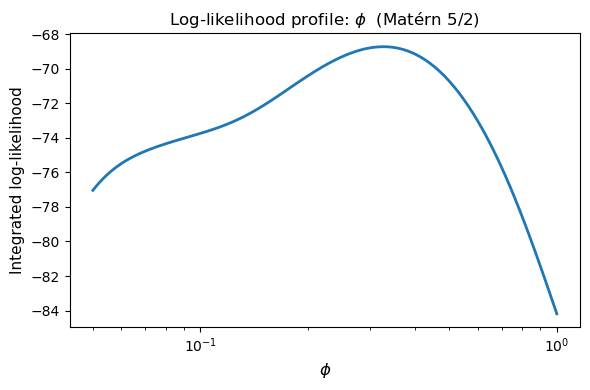

In [13]:
# 7a. Single profile: log-lik vs phi (Matérn)
grid, values, ax = plot_loglik(
    X_train, y_train,
    param        = "phi",
    param_range  = (0.05, 1.0),
    fixed_params = {"nu": 2.5, "nugget": 0.05},
    kernel_type  = "matern52",
    log_x        = True,
)
ax.set_title(r"Log-likelihood profile: $\phi$  (Matérn 5/2)")
plt.tight_layout()
plt.show()


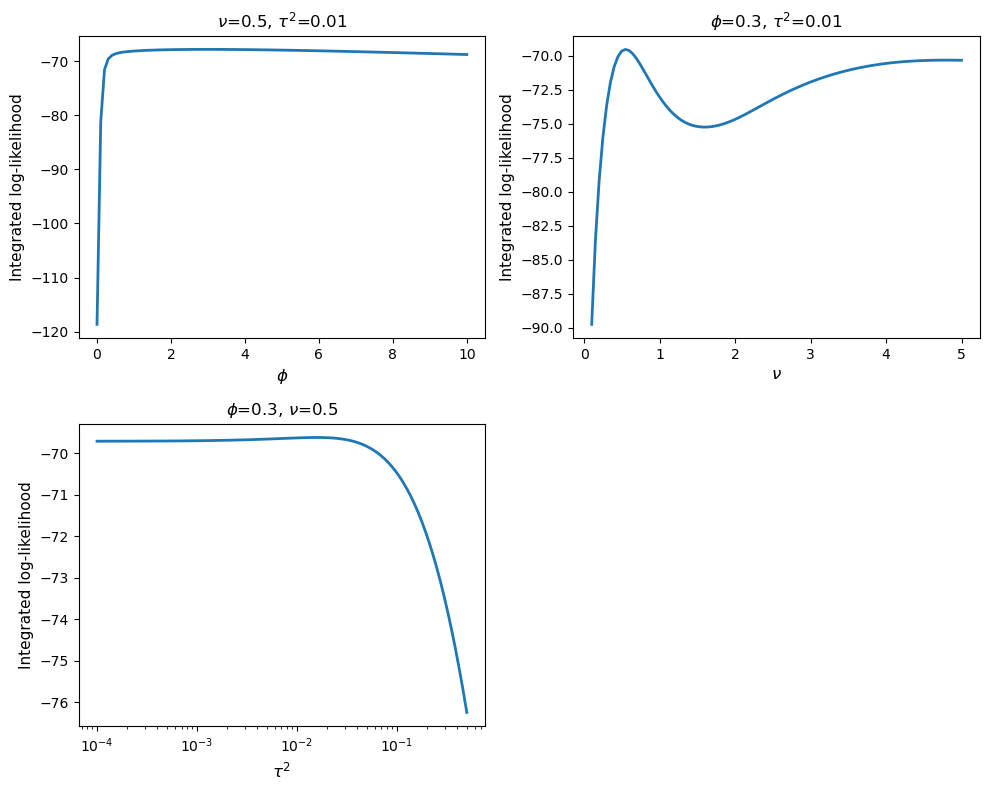

In [14]:
# 7b. Panel of three profiles (Matérn)
specs_matern = [
    dict(param="phi",    param_range=(0.001, 10.0),
         fixed_params={"nu": 0.5, "nugget": 0.01}),
    dict(param="nu",     param_range=(0.1,   5.0),
         fixed_params={"phi": 0.3, "nugget": 0.01}),
    dict(param="nugget", param_range=(1e-4,  0.5),
         fixed_params={"phi": 0.3, "nu": 0.5}, log_x=True),
]
fig, axes = plot_loglik_panel(
    X_train, y_train, specs_matern, kernel_type="matern", ncols=2)
plt.tight_layout()
plt.show()


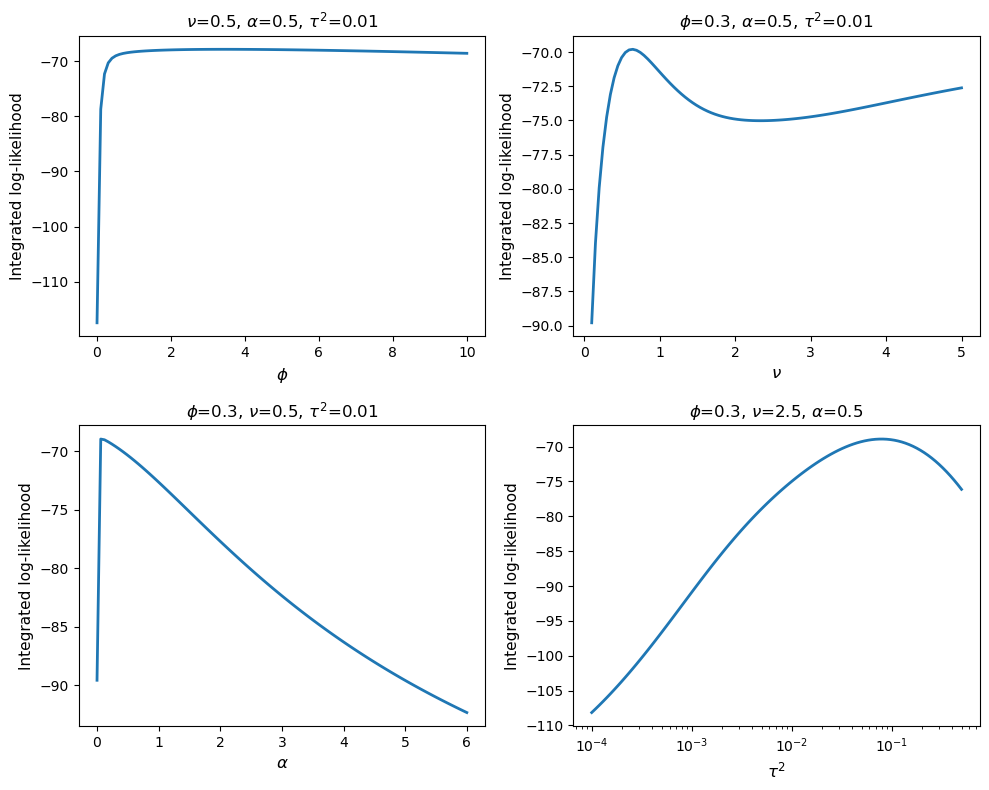

In [15]:
# 7c. Panel of four profiles (CH kernel)
specs_ch = [
    dict(param="phi",    param_range=(0.001, 10.0),
         fixed_params={"nu": 0.5, "tail": 0.5, "nugget": 0.01}),
    dict(param="nu",     param_range=(0.1,   5.0),
         fixed_params={"phi": 0.3, "tail": 0.5, "nugget": 0.01}),
    dict(param="tail",   param_range=(0.001,  6.0),
         fixed_params={"phi": 0.3, "nu":  0.5, "nugget": 0.01}),
    dict(param="nugget", param_range=(1e-4,   0.5),
         fixed_params={"phi": 0.3, "nu":  2.5, "tail": 0.5}, log_x=True),
]
fig, axes = plot_loglik_panel(
    X_train, y_train, specs_ch, kernel_type="ch", ncols=2)
plt.tight_layout()
plt.show()


## 8  Space-time covariance plots


In [16]:
params_st = dict(
    phi          = 0.4,
    tail         = 1.0,
    nu           = 1.5,
    lam0         = 0.6,   # advection magnitude
    theta0       = 0.2,   # advection direction (radians)
    rho          = 0.8,
    lambda1      = 0.8,
    lambda2      = 0.3,
    theta_Lambda = 0.4,
)


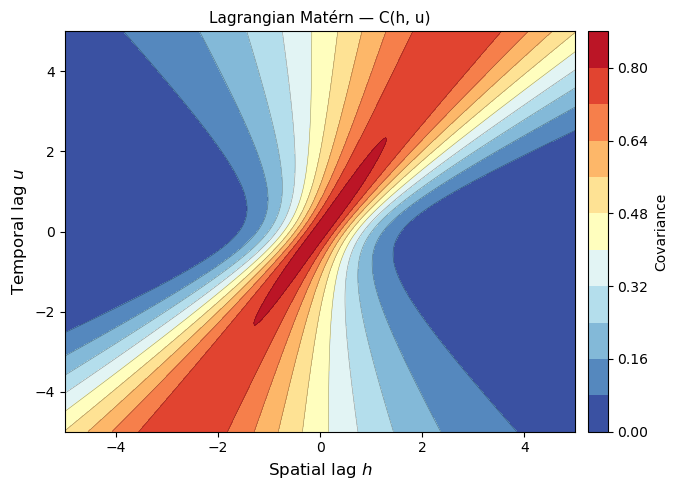

In [17]:
# 8a. 1-D spatial domain: C(h, u) contour
fig, ax = plot_cov_st_1d(
    params_st,
    h_range = (-5, 5),
    u_range = (-5, 5),
    model   = "lagrangian_matern",
    title   = "Lagrangian Matérn — C(h, u)",
)
plt.tight_layout()
plt.show()


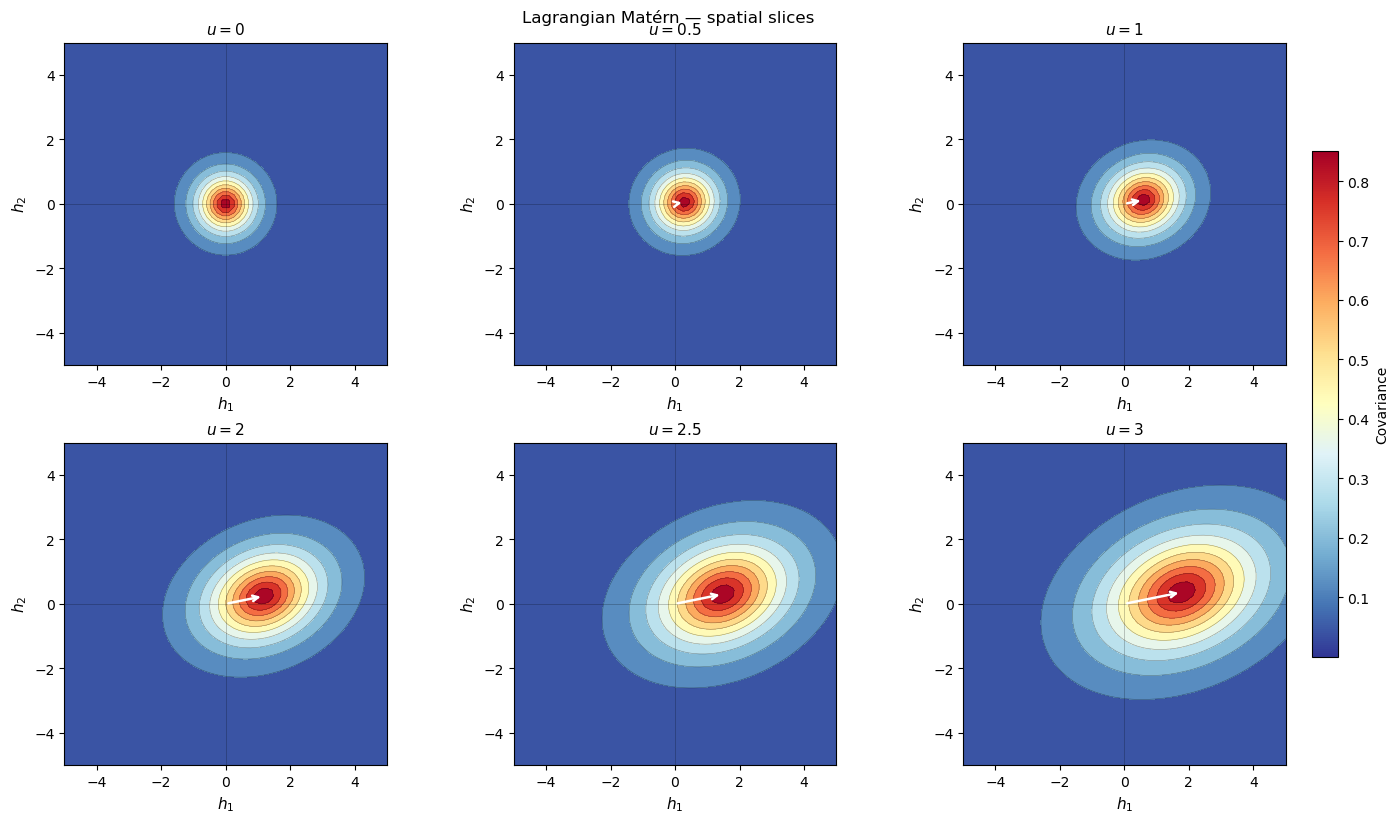

In [18]:
# 8b. 2-D spatial domain: panel of C(h₁, h₂; u) at several time lags
fig, axes = plot_cov_st_2d(
    params_st,
    h_range  = (-5, 5),
    u_values = [0, 0.5, 1.0, 2.0, 2.5, 3.0],
    model    = "lagrangian_matern",
    ncols    = 3,
    n_h      = 60,
    title    = "Lagrangian Matérn — spatial slices",
)
plt.show()


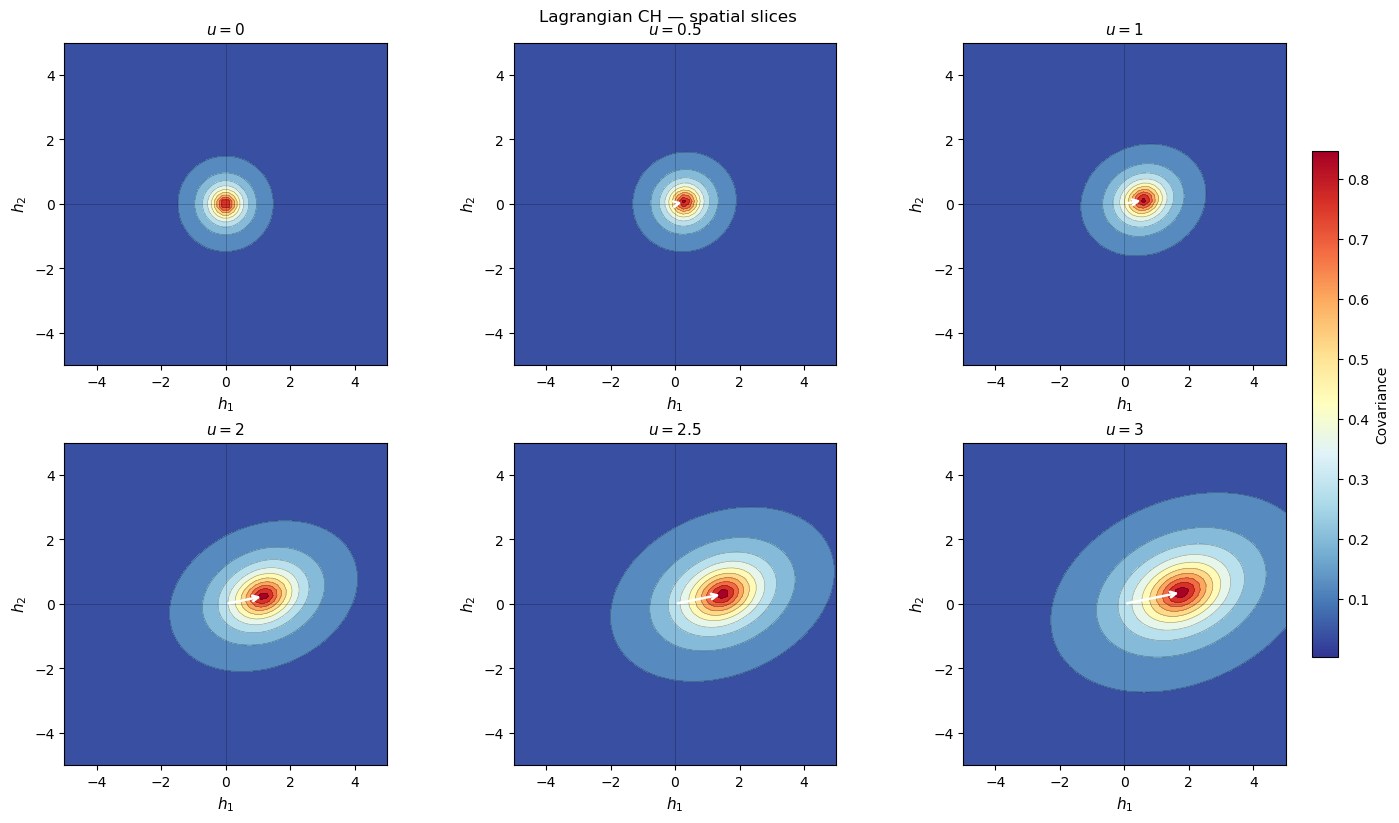

In [19]:
# 8c. Same panel but with the Lagrangian CH kernel
fig, axes = plot_cov_st_2d(
    params_st,
    h_range  = (-5, 5),
    u_values = [0, 0.5, 1.0, 2.0, 2.5, 3.0],
    model    = "lagrangian_ch",
    ncols    = 3,
    n_h      = 60,
    title    = "Lagrangian CH — spatial slices",
)
plt.show()


## 9  Space-time simulation and realisation plots


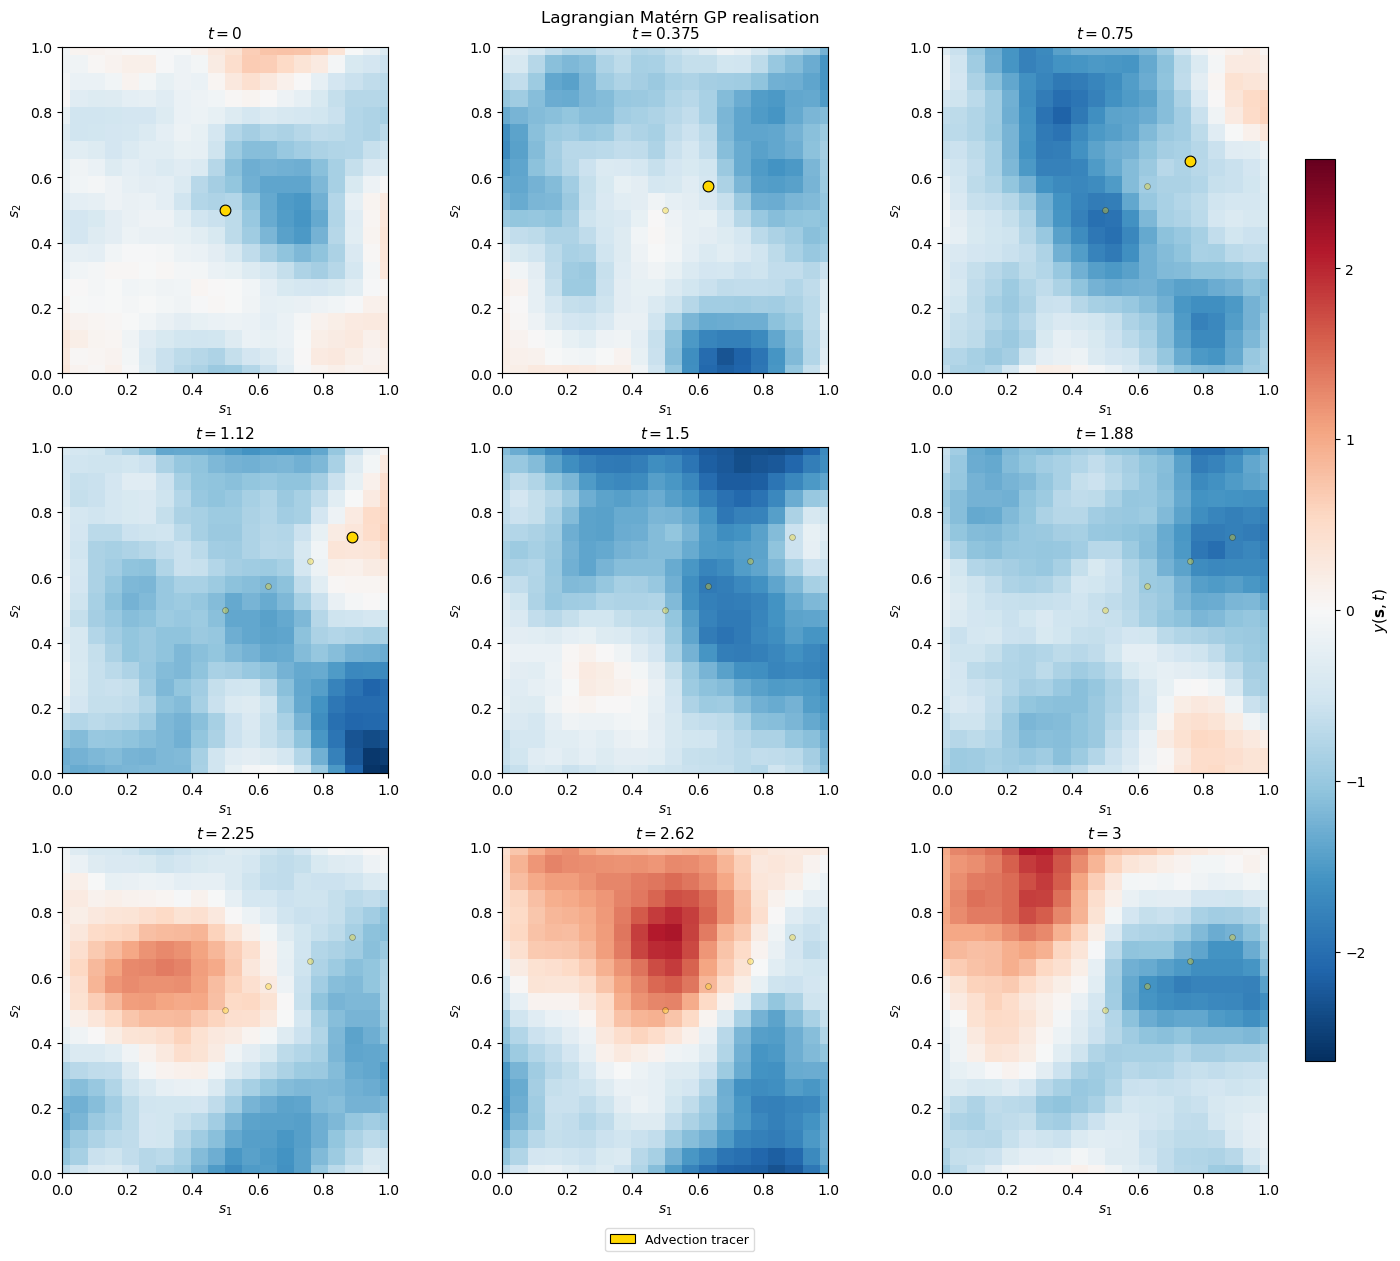

In [2]:
from gpbayeskit.simulation import simulate_st
from gpbayeskit.plotting   import plot_st_realizations
import numpy as np

sim = simulate_st(
    n_space=20,
    t_values=np.linspace(0, 3, 9),
    model="lagrangian_matern",
    phi=0.25, lam0=0.4, theta0=np.deg2rad(30),
    rho=0.5, lambda1=1.5, lambda2=0.5, seed=42,
)

fig, axes = plot_st_realizations(
    sim, ncols=3,
    show_tracer=True,    # gold dot drifts with advection velocity
    show_velocity=True,  # arrow shows advection direction
    title="Lagrangian Matérn GP realisation",
)

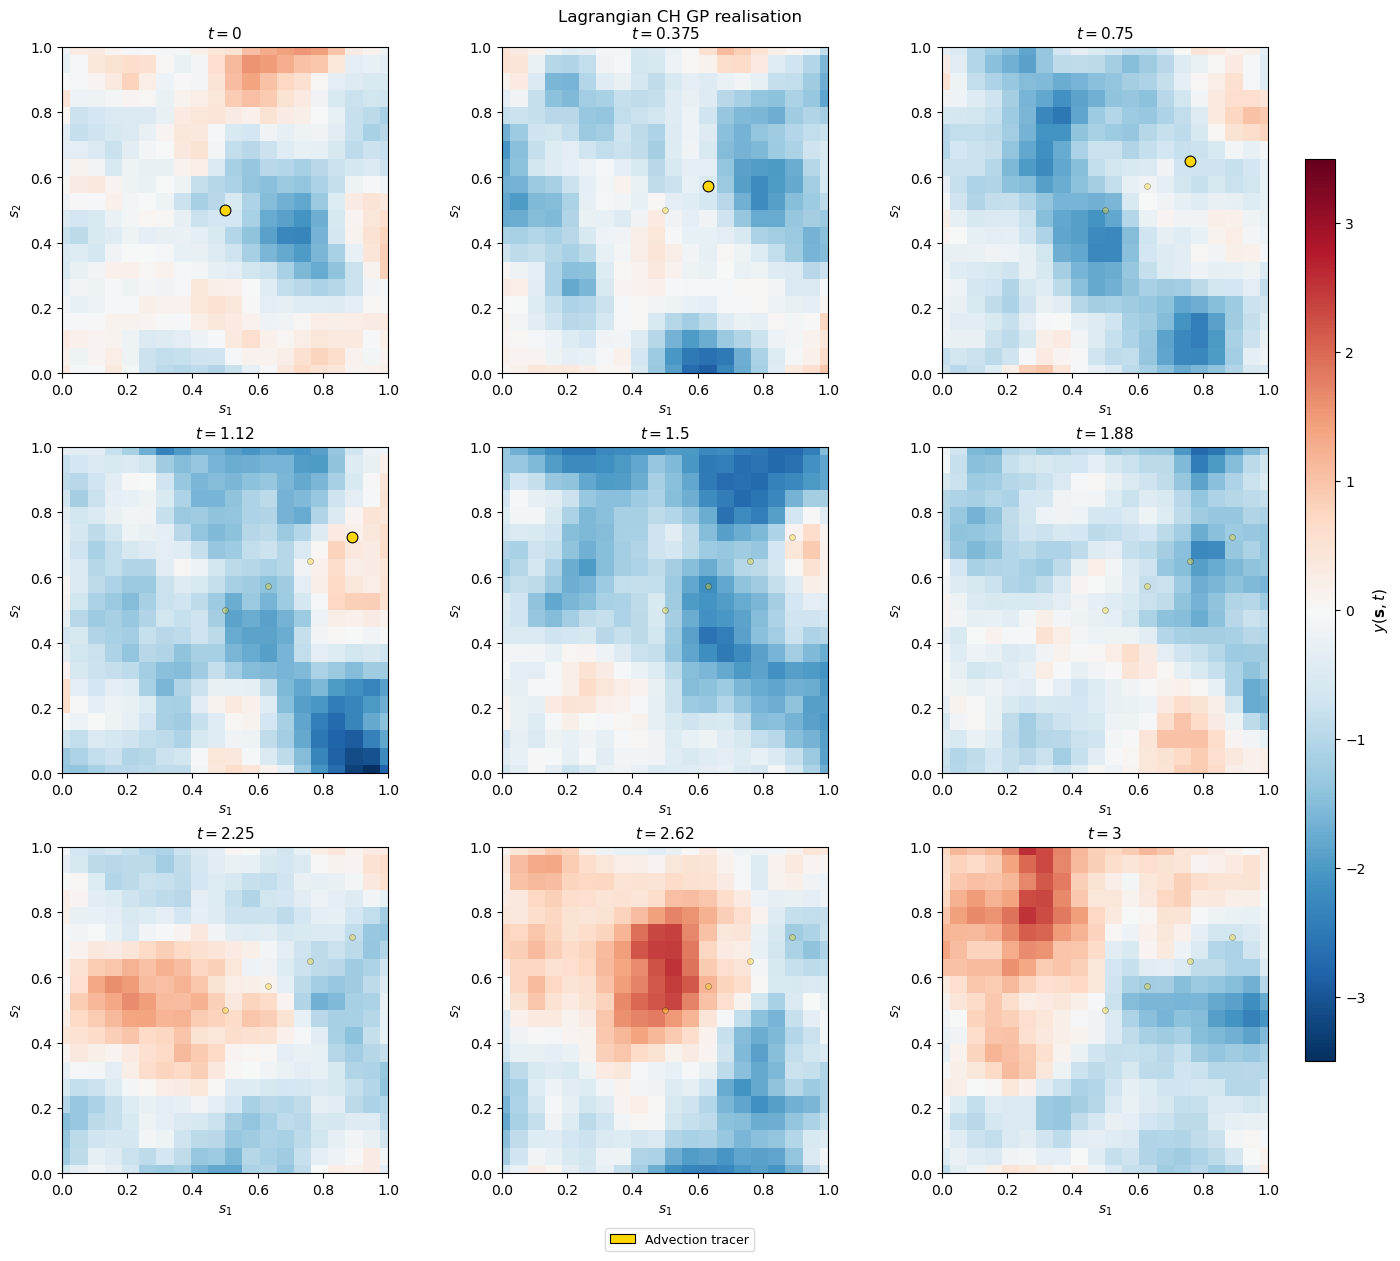

In [3]:
# Lagrangian CH model
sim = simulate_st(
    n_space=20,
    t_values=np.linspace(0, 3, 9),
    model="lagrangian_ch",
    phi=0.25, tail=1.0, lam0=0.4, theta0=np.deg2rad(30),
    rho=0.5, lambda1=1.5, lambda2=0.5, seed=42,
)

fig, axes = plot_st_realizations(
    sim, ncols=3,
    show_tracer=True,    # gold dot drifts with advection velocity
    show_velocity=True,  # arrow shows advection direction
    title="Lagrangian CH GP realisation",
)

In [23]:
?simulate_st


Signature:
simulate_st(
    n_space: 'int | tuple[int, int]' = 20,
    space_range: 'tuple[float, float]' = (0.0, 1.0),
    t_values=None,
    model: 'str' = 'lagrangian_matern',
    sigma2: 'float' = 1.0,
    phi: 'float' = 0.3,
    nu: 'float' = 1.5,
    nugget: 'float' = 0.0001,
    lam0: 'float' = 0.3,
    theta0: 'float' = 0.0,
    rho: 'float' = 1.0,
    lambda1: 'float' = 1.0,
    lambda2: 'float' = 1.0,
    theta_Lambda: 'float' = 0.0,
    seed=None,
) -> 'STSimulationResult'
Docstring:
Simulate one realisation of a spatio-temporal GP on a regular 2-D grid.

Parameters
----------
n_space      : int or (n_h, n_w)
               Spatial grid resolution.  Keep ≤ 25 for fast computation.
space_range  : (lo, hi)  Spatial domain extent for both axes.
t_values     : array_like or None
               Time points.  Defaults to np.linspace(0, 1, 6).
model        : "frozen_matern" | "lagrangian_matern" | "frozen_ch" | "lagrangian_ch"
sigma2       : float  Marginal variance σ².
phi        